<a href="https://colab.research.google.com/github/wndydsr/Praktikum-Pengolahan-Citra/blob/main/Jobsheet5_Mengukur_Kemiripan_Citra.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# JOBSHEET 5 - MENGUKUR KEMIRIPAN CITRA DAN PENERAPANNYA DALAM PENGENALAN POLA

Nama: Windy Destiana Sari  
NIM: 3.34.23.3.25

Kelas: IK-3D  
Mata Kuliah: Pengolahan Citra

###**Menghitung Jarak Berbasis Piksel (Euclidean & Manhattan)**

Jarak Euclidean antara Patch 1 dan Patch 2: 24.7650
Jarak Euclidean antara Patch 1 dan Patch 3: 5.0000
Jarak Manhattan antara Patch 1 dan Patch 2: 936.4392
Jarak Manhattan antara Patch 1 dan Patch 3: 250.0000


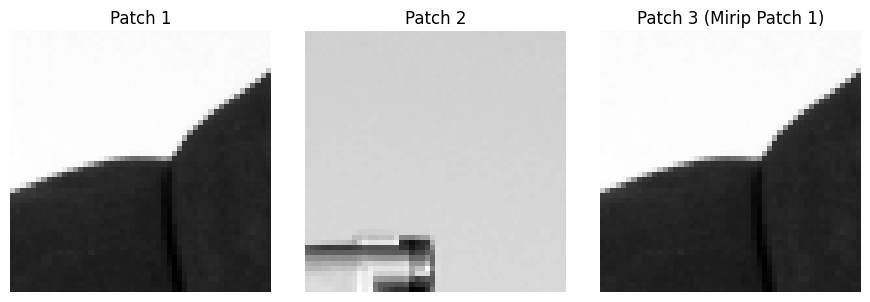

In [ ]:
import numpy as np
from skimage import data, img_as_float
from scipy.spatial import distance
import matplotlib.pyplot as plt

# 1. Buat dua patch citra sederhana atau ambil dari citra asli
image = img_as_float(data.camera())
patch1 = image[100:150, 100:150]
patch2 = image[100:150, 300:350]  # Patch dari lokasi berbeda
patch3 = patch1 + 0.1  # Patch1 dengan sedikit noise/perubahan intensitas
patch3 = np.clip(patch3, 0, 1)  # Pastikan nilai tetap di [0, 1]

# 2. Flatten patch menjadi vektor 1D
vec1 = patch1.flatten()
vec2 = patch2.flatten()
vec3 = patch3.flatten()

# 3. Hitung Jarak Euclidean (L2)
dist_l2_12 = distance.euclidean(vec1, vec2)
dist_l2_13 = distance.euclidean(vec1, vec3)

# 4. Hitung Jarak Manhattan (L1 - disebut 'cityblock' di scipy)
dist_l1_12 = distance.cityblock(vec1, vec2)
dist_l1_13 = distance.cityblock(vec1, vec3)

# 5. Tampilkan hasil dan patch
print(f"Jarak Euclidean antara Patch 1 dan Patch 2: {dist_l2_12:.4f}")
print(f"Jarak Euclidean antara Patch 1 dan Patch 3: {dist_l2_13:.4f}")
print(f"Jarak Manhattan antara Patch 1 dan Patch 2: {dist_l1_12:.4f}")
print(f"Jarak Manhattan antara Patch 1 dan Patch 3: {dist_l1_13:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(9, 3))

axes[0].imshow(patch1, cmap='gray')
axes[0].set_title('Patch 1')
axes[0].axis('off')

axes[1].imshow(patch2, cmap='gray')
axes[1].set_title('Patch 2')
axes[1].axis('off')

axes[2].imshow(patch3, cmap='gray')
axes[2].set_title('Patch 3 (Mirip Patch 1)')
axes[2].axis('off')

plt.tight_layout()
plt.show()

###**Menghitung Cosine Similarity antara Histogram Warna**

Cosine Similarity antara Image 1 dan Image 2: 0.8156
Cosine Similarity antara Image 1 dan Image 3: 1.0000
Cosine Similarity antara Image 1 dan Image 4: 1.0000


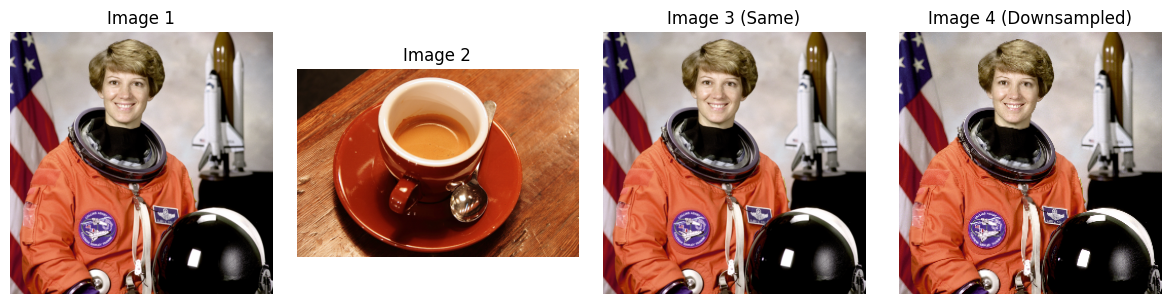

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, img_as_ubyte, io, color
from scipy.spatial import distance

# Fungsi untuk menghitung histogram RGB gabungan
def calculate_rgb_histogram(image, bins=16):
    img_uint8 = img_as_ubyte(image)

    hist_r, _ = np.histogram(img_uint8[:, :, 0].ravel(), bins=bins, range=(0, 256))
    hist_g, _ = np.histogram(img_uint8[:, :, 1].ravel(), bins=bins, range=(0, 256))
    hist_b, _ = np.histogram(img_uint8[:, :, 2].ravel(), bins=bins, range=(0, 256))

    # Gabungkan histogram R, G, B menjadi satu vektor fitur
    hist_combined = np.concatenate((hist_r, hist_g, hist_b))

    # Normalisasi (opsional, tapi sering dilakukan)
    hist_combined = hist_combined.astype(float) / np.sum(hist_combined)

    return hist_combined

# 1. Muat dua citra berwarna
try:
    image1 = data.astronaut()
    image2 = data.coffee()
    image3 = data.astronaut()
    image4 = image1[::2, ::2, :]
except Exception as e:
    print(f"Gagal memuat data skimage: {e}. Membuat citra dummy.")
    image1 = np.random.rand(100, 100, 3)
    image2 = np.random.rand(100, 100, 3) * 0.5
    image3 = image1.copy()
    image4 = image1[::2, ::2, :]

# 2. Hitung histogram untuk setiap citra
hist1 = calculate_rgb_histogram(image1)
hist2 = calculate_rgb_histogram(image2)
hist3 = calculate_rgb_histogram(image3)
hist4 = calculate_rgb_histogram(image4)

# 3. Hitung Cosine Similarity (1 - Cosine Distance)
sim_12 = 1 - distance.cosine(hist1, hist2)
sim_13 = 1 - distance.cosine(hist1, hist3)
sim_14 = 1 - distance.cosine(hist1, hist4)

# 4. Tampilkan hasil
print(f"Cosine Similarity antara Image 1 dan Image 2: {sim_12:.4f}")
print(f"Cosine Similarity antara Image 1 dan Image 3: {sim_13:.4f}")
print(f"Cosine Similarity antara Image 1 dan Image 4: {sim_14:.4f}")

# Visualisasi (opsional)
fig, axes = plt.subplots(1, 4, figsize=(12, 3))

axes[0].imshow(image1)
axes[0].set_title('Image 1')
axes[0].axis('off')

axes[1].imshow(image2)
axes[1].set_title('Image 2')
axes[1].axis('off')

axes[2].imshow(image3)
axes[2].set_title('Image 3 (Same)')
axes[2].axis('off')

axes[3].imshow(image4)
axes[3].set_title('Image 4 (Downsampled)')
axes[3].axis('off')

plt.tight_layout()
plt.show()

###**Menghitung Structural Similarity Index (SSIM)**

SSIM (Ref vs Same): 1.0000
SSIM (Ref vs Noisy): 0.2961
SSIM (Ref vs Contrast): 0.9651
SSIM (Ref vs Blurred): 0.8027


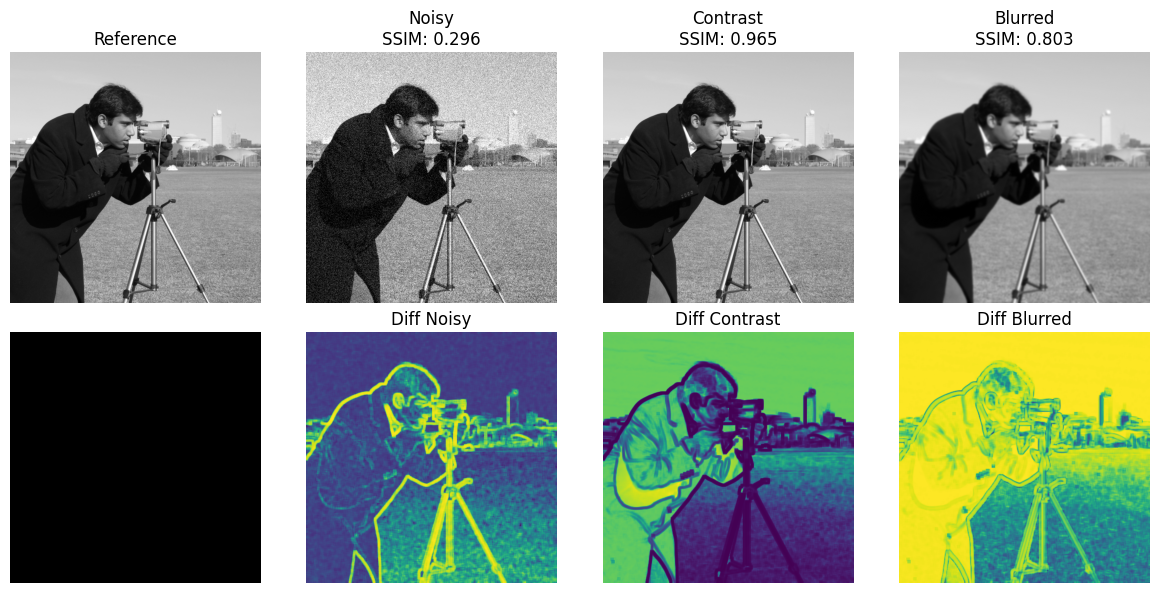

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, img_as_float
from skimage.metrics import structural_similarity as ssim
from skimage.transform import resize
from skimage.util import random_noise
from skimage.filters import gaussian

# 1. Muat citra referensi
image_ref = img_as_float(data.camera())

# 2. Buat variasi citra
image_same = image_ref.copy()

image_noisy = random_noise(image_ref, mode='gaussian', var=0.01)

image_contrast = np.clip(image_ref * 0.8, 0, 1)

image_blurred = gaussian(image_ref, sigma=1.5, channel_axis=None)

# 3. Hitung SSIM
data_range = image_ref.max() - image_ref.min()

ssim_same, _ = ssim(image_ref, image_same, data_range=data_range, full=True)
ssim_noisy, diff_noisy = ssim(image_ref, image_noisy, data_range=data_range, full=True)
ssim_contrast, diff_contrast = ssim(image_ref, image_contrast, data_range=data_range, full=True)
ssim_blurred, diff_blurred = ssim(image_ref, image_blurred, data_range=data_range, full=True)

# 4. Output hasil
print(f"SSIM (Ref vs Same): {ssim_same:.4f}")
print(f"SSIM (Ref vs Noisy): {ssim_noisy:.4f}")
print(f"SSIM (Ref vs Contrast): {ssim_contrast:.4f}")
print(f"SSIM (Ref vs Blurred): {ssim_blurred:.4f}")

# 5. Visualisasi
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
ax = axes.ravel()

ax[0].imshow(image_ref, cmap='gray')
ax[0].set_title('Reference')
ax[0].axis('off')

ax[1].imshow(image_noisy, cmap='gray')
ax[1].set_title(f'Noisy\nSSIM: {ssim_noisy:.3f}')
ax[1].axis('off')

ax[2].imshow(image_contrast, cmap='gray')
ax[2].set_title(f'Contrast\nSSIM: {ssim_contrast:.3f}')
ax[2].axis('off')

ax[3].imshow(image_blurred, cmap='gray')
ax[3].set_title(f'Blurred\nSSIM: {ssim_blurred:.3f}')
ax[3].axis('off')

ax[4].imshow(np.zeros_like(image_ref), cmap='gray')
ax[4].axis('off')

ax[5].imshow(diff_noisy, cmap='viridis')
ax[5].set_title('Diff Noisy')
ax[5].axis('off')

ax[6].imshow(diff_contrast, cmap='viridis')
ax[6].set_title('Diff Contrast')
ax[6].axis('off')

ax[7].imshow(diff_blurred, cmap='viridis')
ax[7].set_title('Diff Blurred')
ax[7].axis('off')

plt.tight_layout()
plt.show()

###**Penerapan Template Matching**

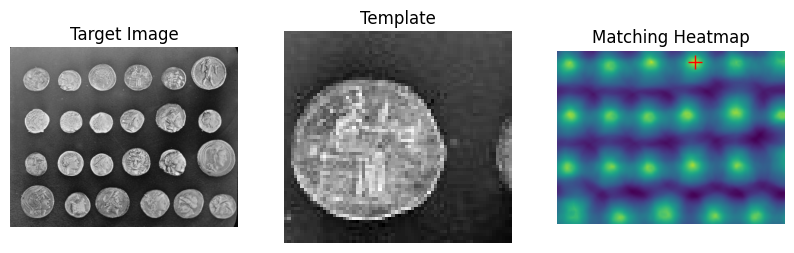

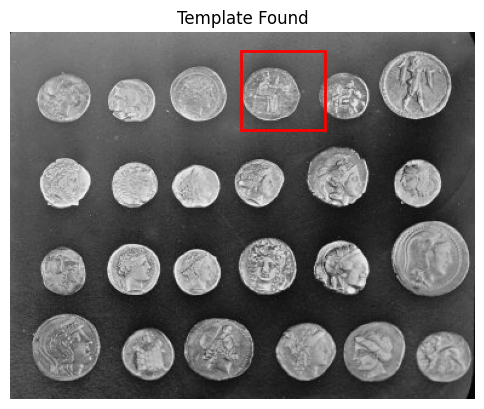

Template ditemukan di koordinat (x, y): (190, 15)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from skimage.feature import match_template

# 1. Muat citra target dan template
image = data.coins()
template = image[15:80, 190:260]

# 2. Template matching
result = match_template(image, template)

# 3. Lokasi terbaik
ij = np.unravel_index(np.argmax(result), result.shape)
x, y = ij[::-1]

# 4. Visualisasi
fig, ax = plt.subplots(1, 3, figsize=(10, 4))

ax[0].imshow(image, cmap='gray')
ax[0].set_title('Target Image')
ax[0].axis('off')

ax[1].imshow(template, cmap='gray')
ax[1].set_title('Template')
ax[1].axis('off')

ax[2].imshow(result, cmap='viridis')
ax[2].set_title('Matching Heatmap')
ax[2].axis('off')
ax[2].plot(x, y, 'r+', markersize=10)

fig2, ax_main = plt.subplots(figsize=(6, 6))
ax_main.imshow(image, cmap='gray')
ax_main.set_title('Template Found')
ax_main.axis('off')

h, w = template.shape
rect = plt.Rectangle((x, y), w, h, edgecolor='r', facecolor='none', lw=2)
ax_main.add_patch(rect)

plt.show()

print(f"Template ditemukan di koordinat (x, y): ({x}, {y})")

###**Simulasi Content-Based Image Retrieval (CBIR) Sederhana**


Hasil Retrieval:
Rank 1: chelsea (Distance: 0.000)
Rank 2: coins (Distance: 0.288)
Rank 3: coffee (Distance: 0.359)
Rank 4: astronaut (Distance: 0.461)
Rank 5: camera (Distance: 0.602)


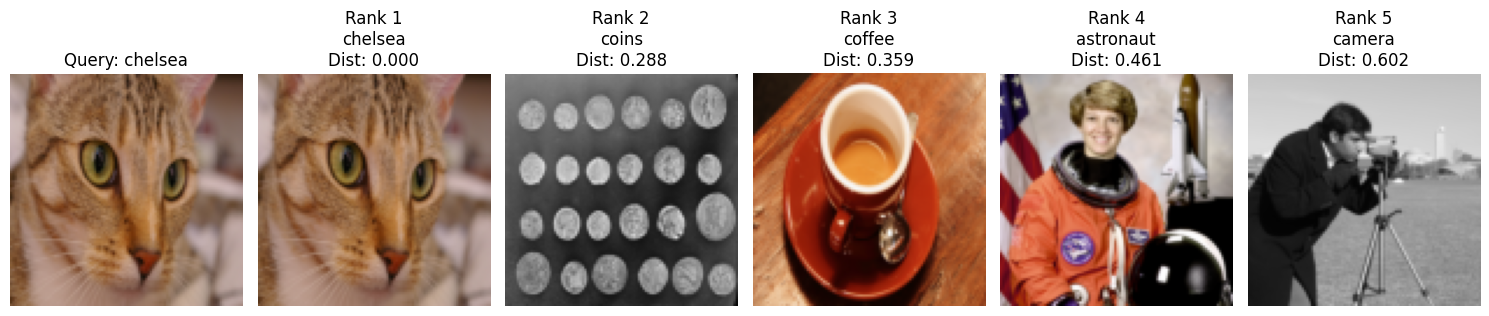

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, color, transform, img_as_ubyte
from scipy.spatial import distance

def calculate_rgb_histogram(image, bins=16):
    if image.dtype == float:
        image = img_as_ubyte(image)

    hist_r, _ = np.histogram(image[:, :, 0].ravel(), bins=bins, range=(0, 256))
    hist_g, _ = np.histogram(image[:, :, 1].ravel(), bins=bins, range=(0, 256))
    hist_b, _ = np.histogram(image[:, :, 2].ravel(), bins=bins, range=(0, 256))

    hist = np.concatenate((hist_r, hist_g, hist_b))

    if np.sum(hist) > 0:
        hist = hist.astype(float) / np.sum(hist)

    return hist


# Database
image_db_names = ["astronaut", "camera", "coffee", "coins", "chelsea"]
database_images = []
database_hists = []

for name in image_db_names:
    img = getattr(data, name)()

    if img.ndim == 2:
        img = color.gray2rgb(img)

    img = transform.resize(img, (100, 100), anti_aliasing=True)

    database_images.append(img)
    database_hists.append(calculate_rgb_histogram(img))


# Query
query_name = "chelsea"
query_index = image_db_names.index(query_name)

query_hist = database_hists[query_index]

# Hitung jarak
distances = []
for hist in database_hists:
    distances.append(distance.cosine(query_hist, hist))

# Sorting
sorted_indices = np.argsort(distances)

# Visualisasi
fig, axes = plt.subplots(1, len(database_images) + 1, figsize=(15, 3))

axes[0].imshow(database_images[query_index])
axes[0].set_title(f"Query: {query_name}")
axes[0].axis('off')

print("\nHasil Retrieval:")

for rank, idx in enumerate(sorted_indices, start=1):
    axes[rank].imshow(database_images[idx])
    axes[rank].set_title(
        f"Rank {rank}\n{image_db_names[idx]}\nDist: {distances[idx]:.3f}"
    )
    axes[rank].axis('off')

    print(f"Rank {rank}: {image_db_names[idx]} (Distance: {distances[idx]:.3f})")

plt.tight_layout()
plt.show()

##**TUGAS**


Hasil Retrieval (Mean RGB):
Rank 1: chelsea (Distance: 0.000)
Rank 2: astronaut (Distance: 0.050)
Rank 3: coffee (Distance: 0.176)
Rank 4: camera (Distance: 0.194)
Rank 5: coins (Distance: 0.211)


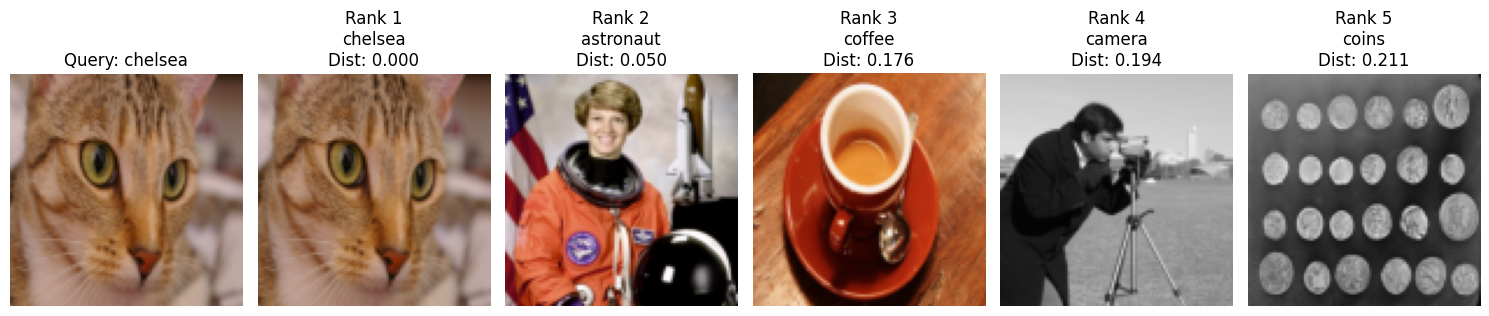

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, color, transform
from scipy.spatial import distance

# Hitung fitur: mean R, G, B
def calculate_mean_rgb(image):
    return np.mean(image, axis=(0, 1))

# Database
image_db_names = ["astronaut", "camera", "coffee", "coins", "chelsea"]
database_images = []
database_feats = []

for name in image_db_names:
    img = getattr(data, name)()

    if img.ndim == 2:
        img = color.gray2rgb(img)

    img = transform.resize(img, (100, 100), anti_aliasing=True)

    database_images.append(img)
    database_feats.append(calculate_mean_rgb(img))

# Query
query_name = "chelsea"
query_index = image_db_names.index(query_name)

query_feat = database_feats[query_index]

# Hitung jarak Euclidean
distances = []
for feat in database_feats:
    dist = distance.euclidean(query_feat, feat)
    distances.append(dist)

# Sorting
sorted_indices = np.argsort(distances)

# Visualisasi
fig, axes = plt.subplots(1, len(database_images) + 1, figsize=(15, 3))

axes[0].imshow(database_images[query_index])
axes[0].set_title(f"Query: {query_name}")
axes[0].axis('off')

print("\nHasil Retrieval (Mean RGB):")

for rank, idx in enumerate(sorted_indices, start=1):
    axes[rank].imshow(database_images[idx])
    axes[rank].set_title(
        f"Rank {rank}\n{image_db_names[idx]}\nDist: {distances[idx]:.3f}"
    )
    axes[rank].axis('off')

    print(f"Rank {rank}: {image_db_names[idx]} (Distance: {distances[idx]:.3f})")

plt.tight_layout()
plt.show()

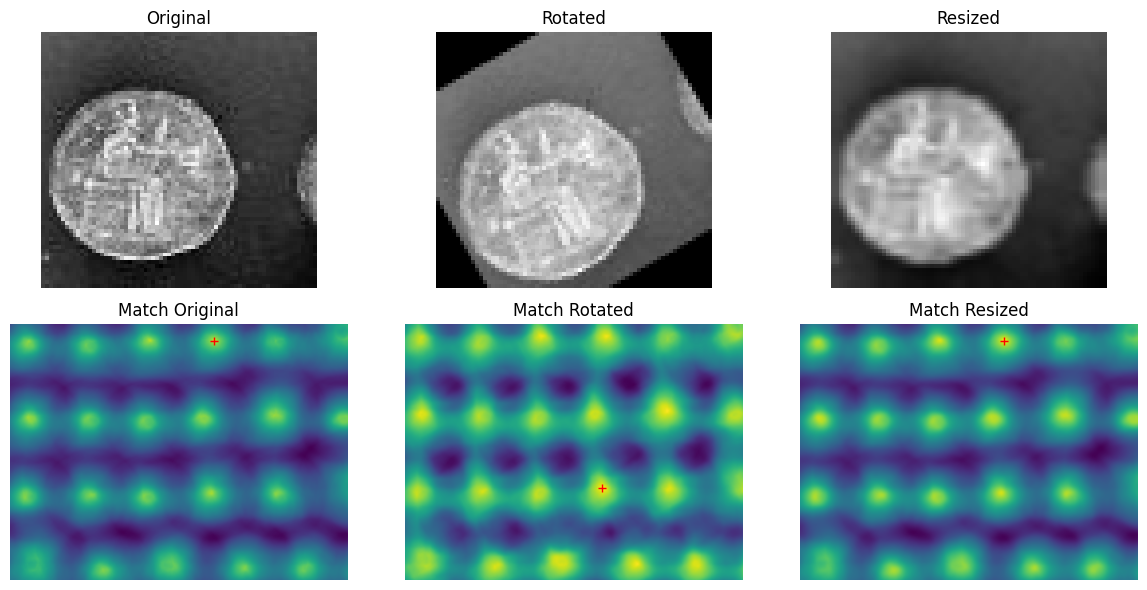

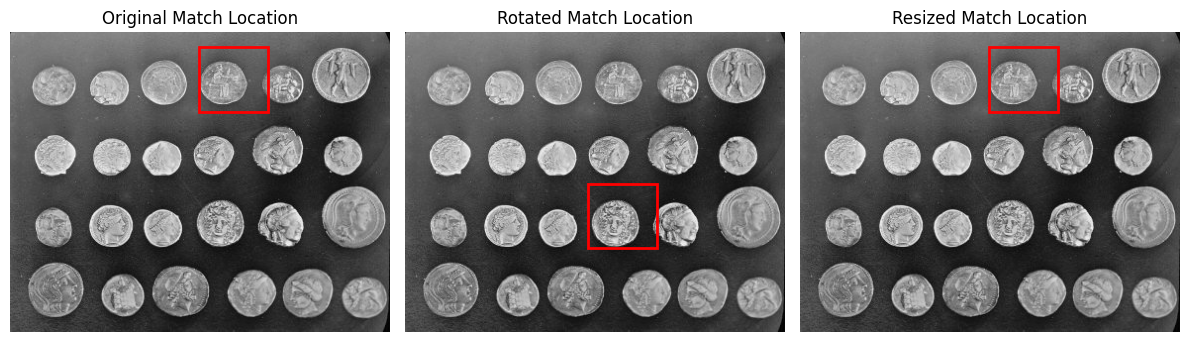

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, transform
from skimage.feature import match_template

image = data.coins()
template = image[15:80, 190:260]

template_original = template
template_rotated = transform.rotate(template, angle=30, resize=False)
template_resized = transform.resize(template, (template.shape[0]//2, template.shape[1]//2))
template_resized = transform.resize(template_resized, template.shape)

result_original = match_template(image, template_original)
result_rotated = match_template(image, template_rotated)
result_resized = match_template(image, template_resized)

def get_best(result):
    ij = np.unravel_index(np.argmax(result), result.shape)
    return ij[::-1]

x1, y1 = get_best(result_original)
x2, y2 = get_best(result_rotated)
x3, y3 = get_best(result_resized)

fig, axes = plt.subplots(2, 3, figsize=(12, 6))

axes[0,0].imshow(template_original, cmap='gray')
axes[0,0].set_title("Original")
axes[0,0].axis('off')

axes[0,1].imshow(template_rotated, cmap='gray')
axes[0,1].set_title("Rotated")
axes[0,1].axis('off')

axes[0,2].imshow(template_resized, cmap='gray')
axes[0,2].set_title("Resized")
axes[0,2].axis('off')

axes[1,0].imshow(result_original, cmap='viridis')
axes[1,0].plot(x1, y1, 'r+')
axes[1,0].set_title("Match Original")
axes[1,0].axis('off')

axes[1,1].imshow(result_rotated, cmap='viridis')
axes[1,1].plot(x2, y2, 'r+')
axes[1,1].set_title("Match Rotated")
axes[1,1].axis('off')

axes[1,2].imshow(result_resized, cmap='viridis')
axes[1,2].plot(x3, y3, 'r+')
axes[1,2].set_title("Match Resized")
axes[1,2].axis('off')

plt.tight_layout()
plt.show()

fig2, ax = plt.subplots(1, 3, figsize=(12,4))

ax[0].imshow(image, cmap='gray')
ax[0].add_patch(plt.Rectangle((x1, y1), template.shape[1], template.shape[0],
                              edgecolor='r', facecolor='none', lw=2))
ax[0].set_title("Original Match Location")
ax[0].axis('off')

ax[1].imshow(image, cmap='gray')
ax[1].add_patch(plt.Rectangle((x2, y2), template.shape[1], template.shape[0],
                              edgecolor='r', facecolor='none', lw=2))
ax[1].set_title("Rotated Match Location")
ax[1].axis('off')

ax[2].imshow(image, cmap='gray')
ax[2].add_patch(plt.Rectangle((x3, y3), template.shape[1], template.shape[0],
                              edgecolor='r', facecolor='none', lw=2))
ax[2].set_title("Resized Match Location")
ax[2].axis('off')

plt.tight_layout()
plt.show()